<a href="https://colab.research.google.com/github/tacyataide/Revisao/blob/tacyataide-patch-1/Detec%C3%A7%C3%A3o_de_contornos_com_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

Saving iphone.png to iphone.png


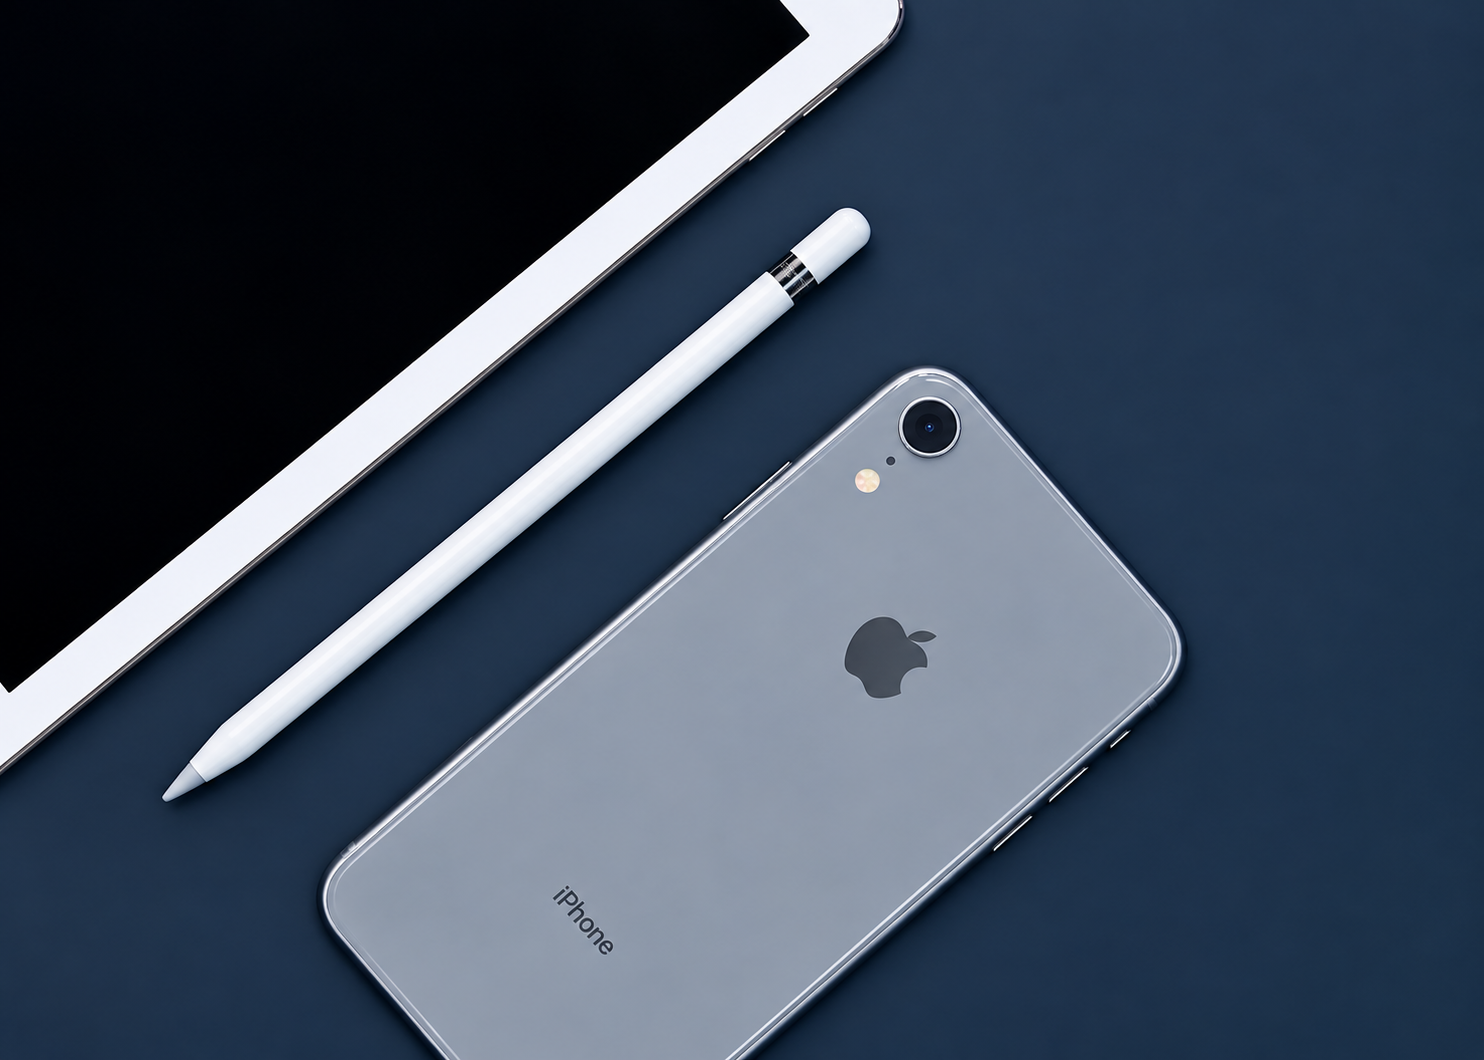

In [63]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path)

cv2_imshow(image)

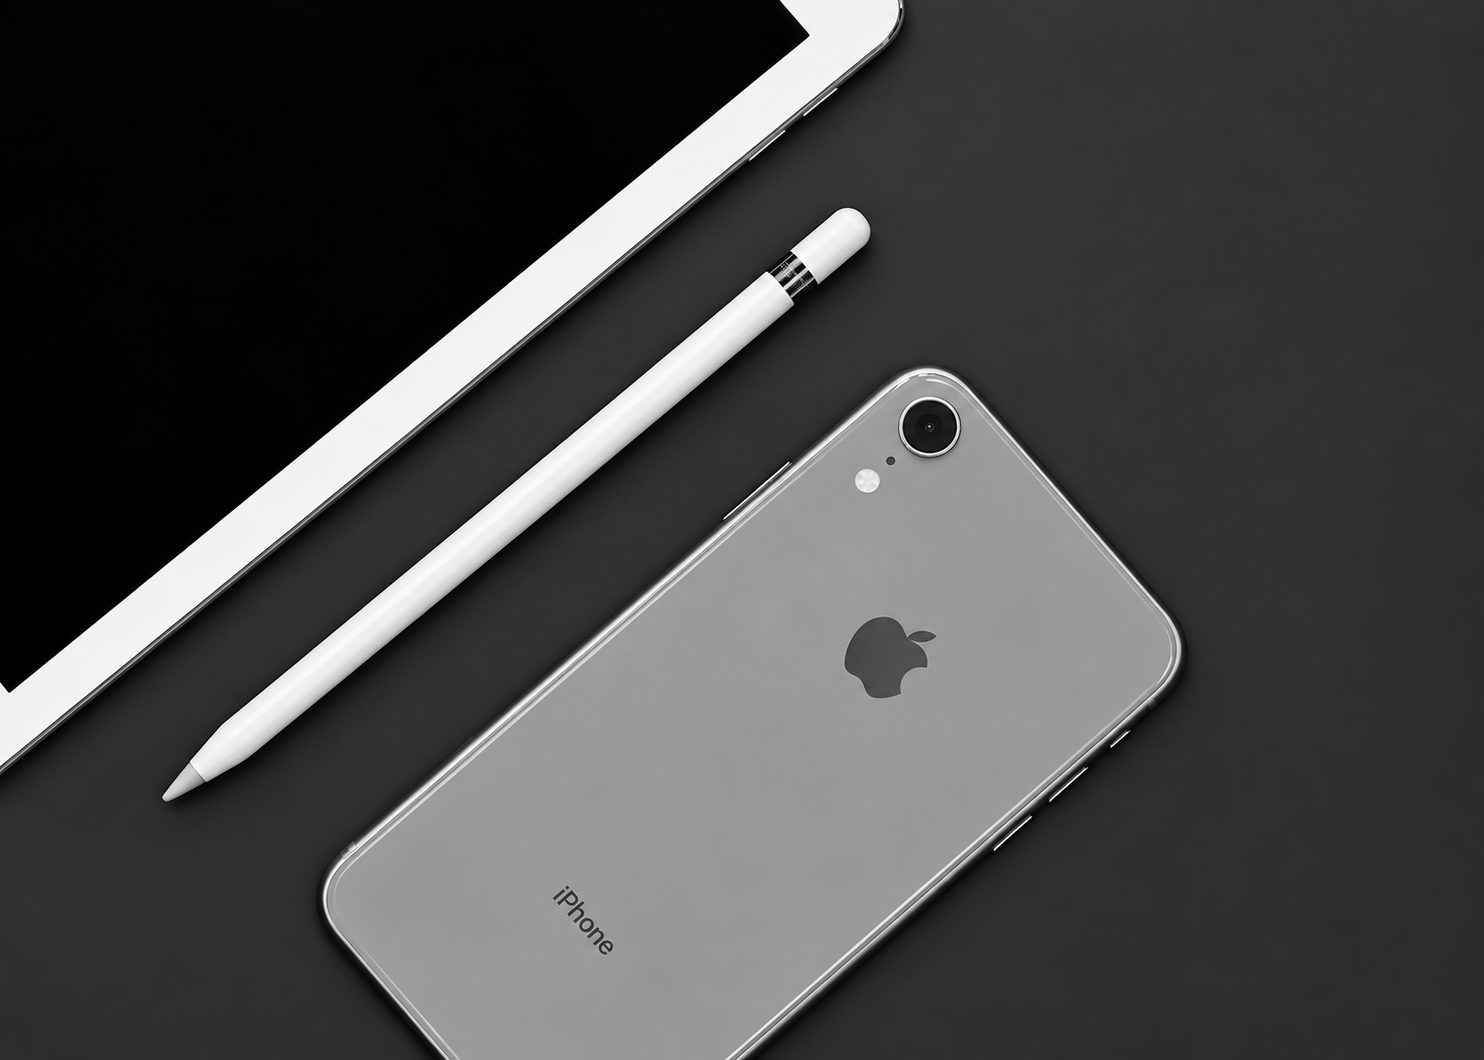

In [64]:
img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cv2_imshow(img_gray)

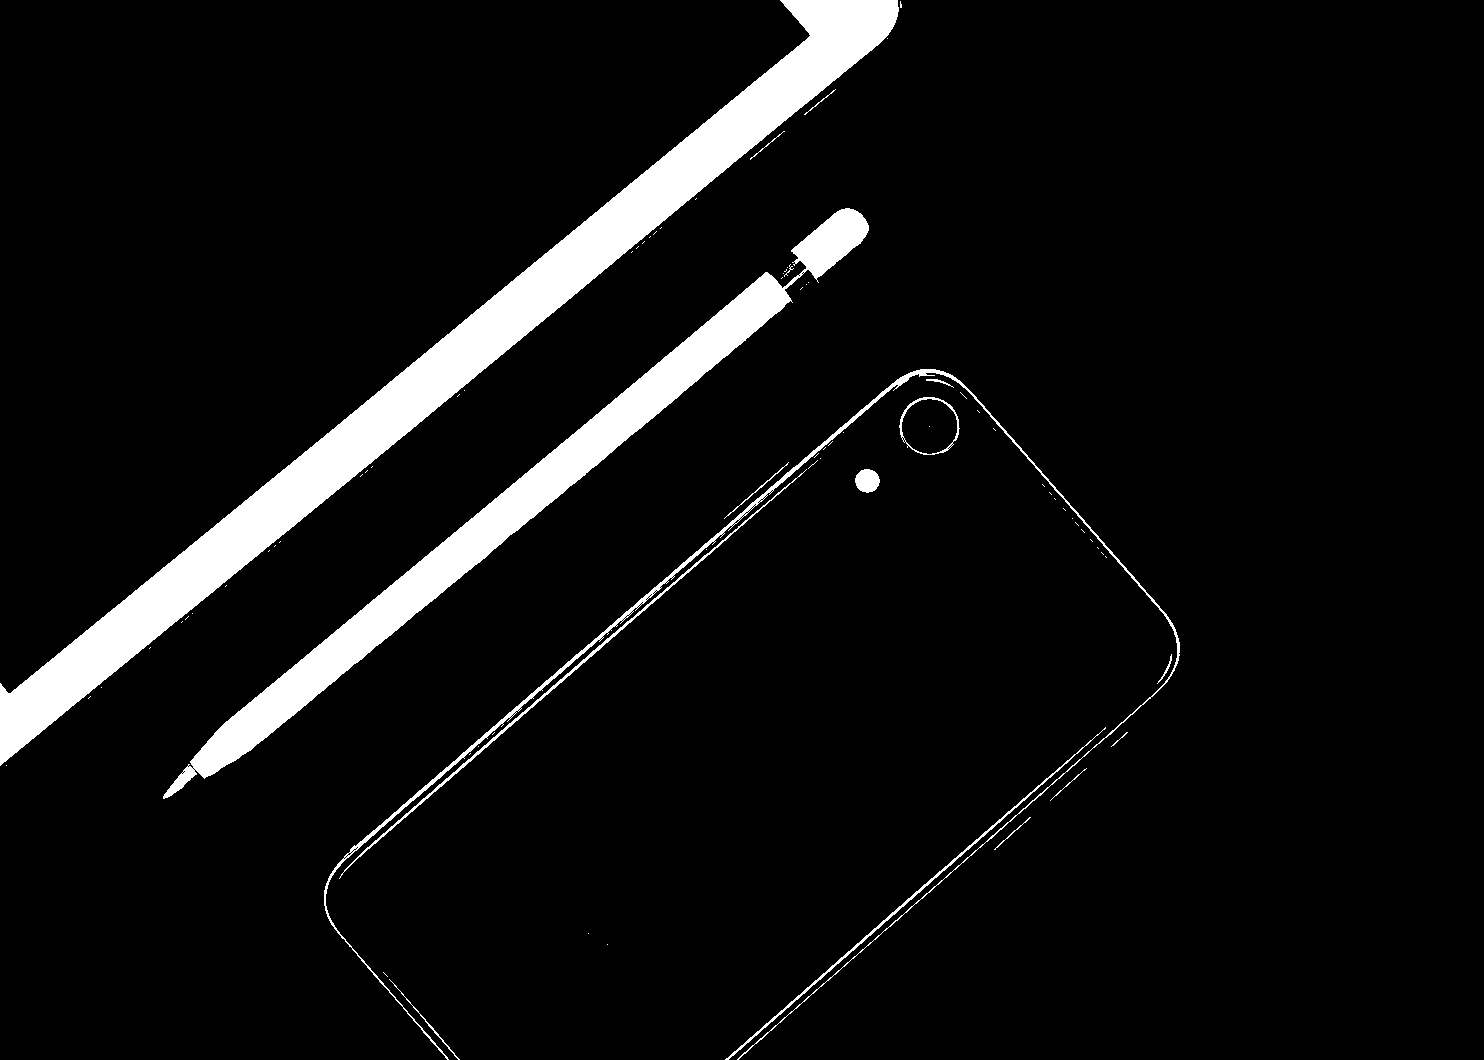

True

In [71]:
ret, thresh = cv2.threshold(
    img_gray,
    190,
    255,
    cv2.THRESH_BINARY
)


cv2_imshow(thresh)

cv2.imwrite("image_thres1.jpg", thresh)

Desenhando contornos com `CHAIN_APPROX_NONE`

Após gerar a imagem binária na etapa anterior, podemos localizar os contornos utilizando a função `cv2.findContours()`.

Neste exemplo, utilizamos:

- `cv2.RETR_TREE`: recupera todos os contornos encontrados na imagem e organiza suas relações hierárquicas.
- `cv2.CHAIN_APPROX_NONE`: armazena todos os pontos que formam cada contorno, sem realizar simplificação.

A função `cv2.findContours()` recebe como entrada a imagem binária obtida anteriormente e retorna os contornos encontrados e sua hierarquia.

Em seguida, fazemos uma cópia da imagem original utilizando `image.copy()`. Essa cópia é usada para desenhar os contornos sem modificar a imagem original.

A função `cv2.drawContours()` desenha os contornos detectados sobre a imagem. Neste exemplo, todos os contornos são desenhados em verde, com espessura de 2 pixels.

Como o código está sendo executado no Google Colab, utilizamos `cv2_imshow()` para exibir o resultado diretamente no notebook.

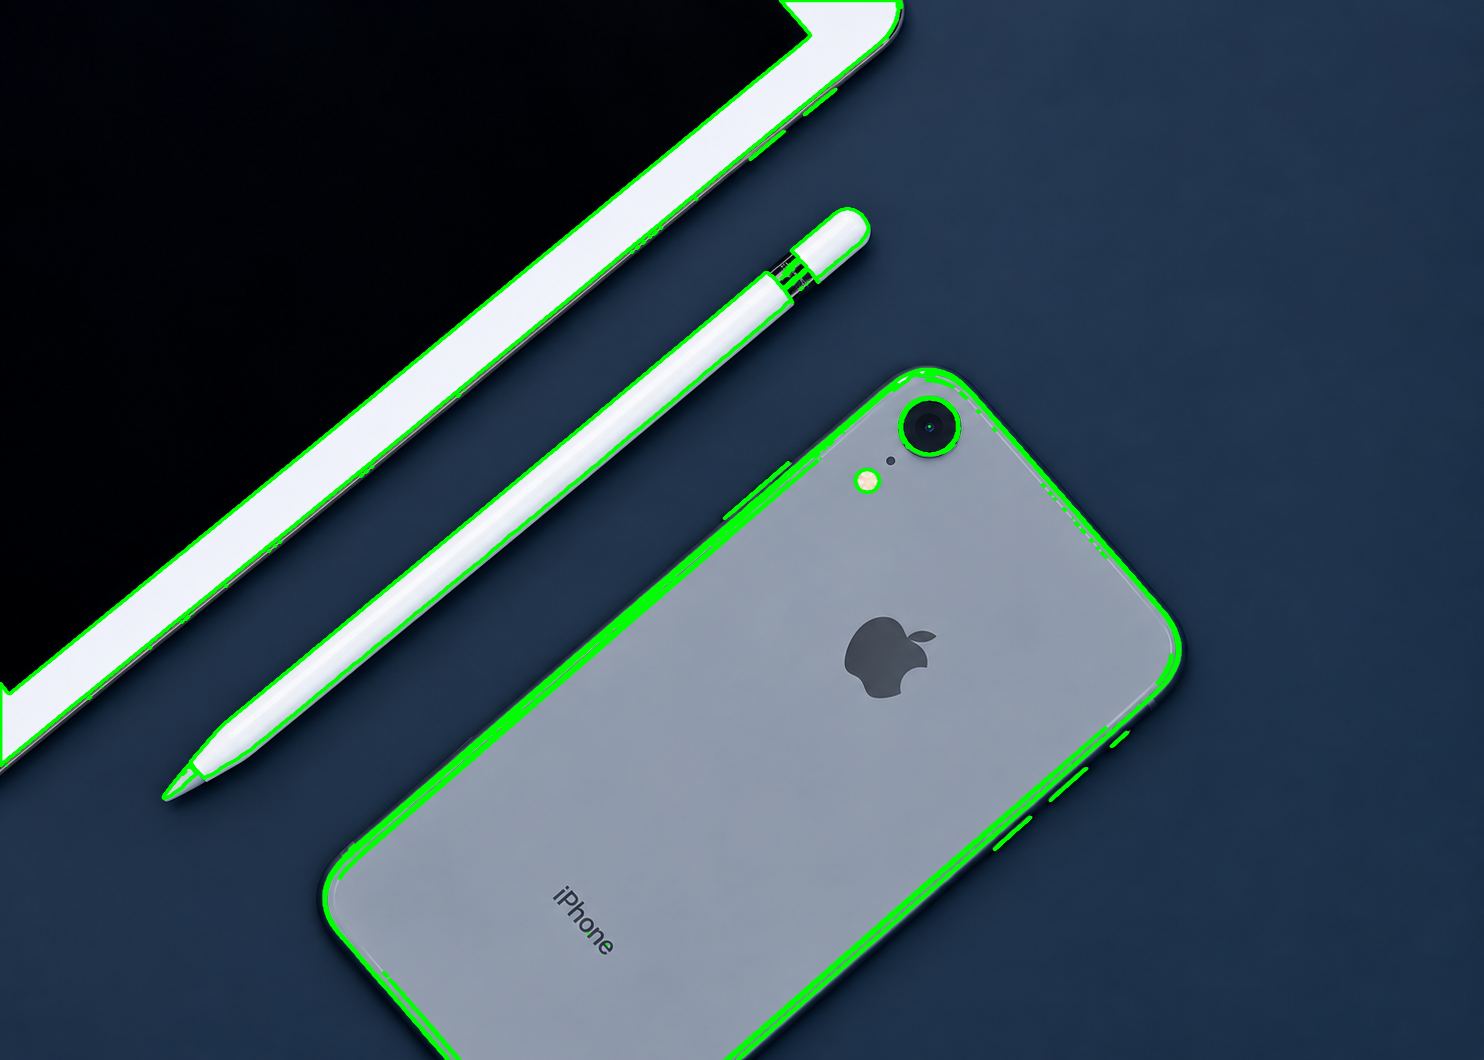

True

In [72]:
# Detecta os contornos na imagem binária usando CHAIN_APPROX_NONE
contours, hierarchy = cv2.findContours(
    image=thresh,
    mode=cv2.RETR_TREE,
    method=cv2.CHAIN_APPROX_NONE
)

# Cria uma cópia da imagem original
image_copy = image.copy()

# Desenha todos os contornos encontrados
cv2.drawContours(
    image=image_copy,
    contours=contours,
    contourIdx=-1,
    color=(0, 255, 0),
    thickness=2,
    lineType=cv2.LINE_AA
)

# Exibe o resultado no Google Colab
cv2_imshow(image_copy)

# Salva a imagem com os contornos
cv2.imwrite("contours_none_image1.jpg", image_copy)

Saving O'REILLY.jpg to O'REILLY (4).jpg
Imagem carregada com sucesso!
Arquivo: O'REILLY (4).jpg
Dimensões: (800, 800, 3)


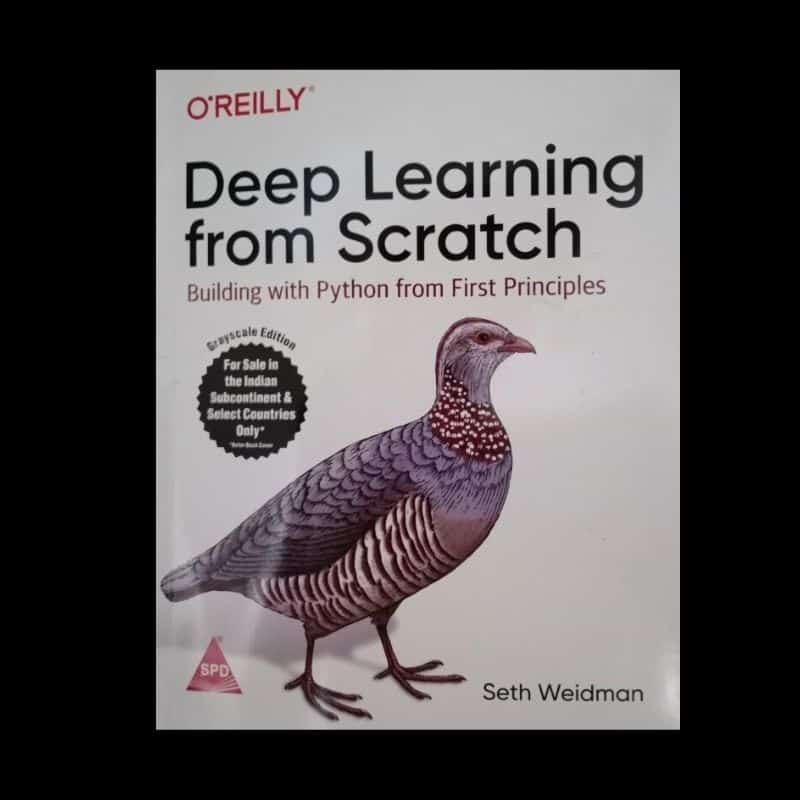

In [86]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

nome_arquivo = next(iter(uploaded))

image1 = cv2.imread(nome_arquivo)

if image1 is None:
    print("Erro: a imagem não pôde ser carregada.")
else:
    print("Imagem carregada com sucesso!")
    print("Arquivo:", nome_arquivo)
    print("Dimensões:", image1.shape)
    cv2_imshow(image1)


Os métodos `CHAIN_APPROX_NONE` e `CHAIN_APPROX_SIMPLE` podem produzir resultados visualmente muito parecidos quando os contornos são desenhados com a função `cv2.drawContours()`.

Isso acontece porque `cv2.drawContours()` conecta automaticamente os pontos adjacentes do contorno. Assim, mesmo que o `CHAIN_APPROX_SIMPLE` armazene menos pontos, o desenho final pode parecer praticamente igual ao resultado obtido com `CHAIN_APPROX_NONE`.

Para observar melhor a diferença, podemos percorrer manualmente os pontos armazenados em cada contorno e desenhar um pequeno círculo em cada coordenada.

Nesta etapa:

- A imagem é convertida para escala de cinza.
- É aplicada uma limiarização binária.
- Os contornos são detectados utilizando `cv2.CHAIN_APPROX_SIMPLE`.
- Os contornos completos são desenhados com `cv2.drawContours()`.
- Em seguida, cada ponto armazenado no contorno é percorrido individualmente.
- Um pequeno círculo verde é desenhado em cada coordenada utilizando `cv2.circle()`.

Dessa forma, é possível visualizar diretamente os pontos que foram realmente armazenados pelo algoritmo `CHAIN_APPROX_SIMPLE`.

Como o código está sendo executado no Google Colab, utilizamos `cv2_imshow()` no lugar de `cv2.imshow()`.

CHAIN_APPROX_SIMPLE:


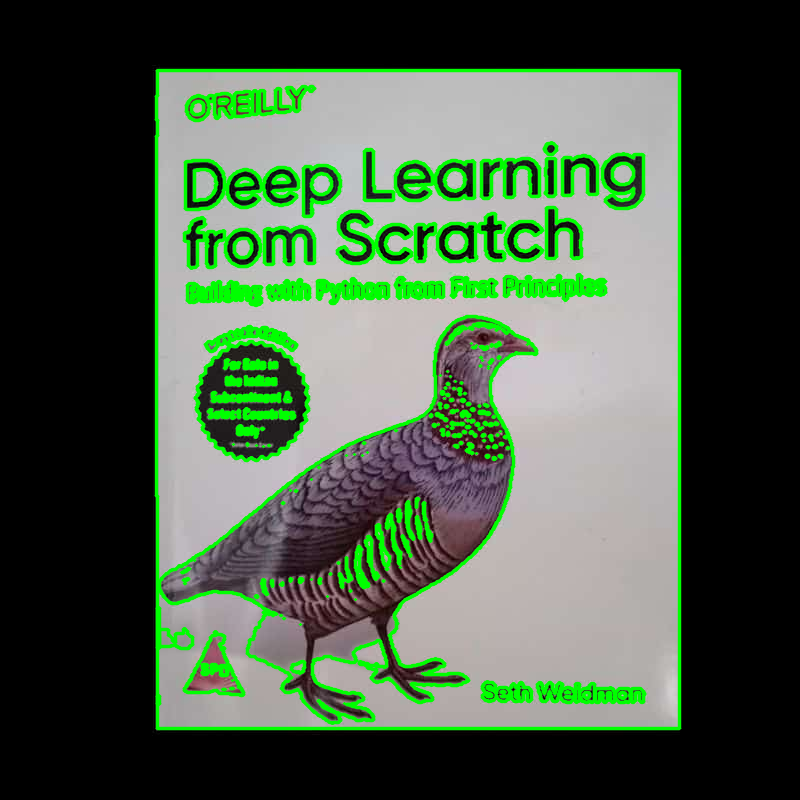

True

In [88]:
# Converte para escala de cinza
img_gray1 = cv2.cvtColor(
    image1,
    cv2.COLOR_BGR2GRAY
)

# Aplica a limiarização binária
ret, thresh1 = cv2.threshold(
    img_gray1,
    150,
    255,
    cv2.THRESH_BINARY
)

# Detecta os contornos com CHAIN_APPROX_SIMPLE
contours2, hierarchy2 = cv2.findContours(
    thresh1,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

# Desenha os contornos
image_copy2 = image1.copy()

cv2.drawContours(
    image_copy2,
    contours2,
    -1,
    (0, 255, 0),
    2,
    cv2.LINE_AA
)

print("CHAIN_APPROX_SIMPLE:")
cv2_imshow(image_copy2)


# Mostra apenas os pontos armazenados
image_copy3 = image1.copy()

for contour in contours2:
    for contour_point in contour:

        x, y = contour_point[0]

        cv2.circle(
            image_copy3,
            (x, y),
            2,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )



cv2.imwrite(
    "contour_point_simple.jpg",
    image_copy3
)

Saving hierarquias.jpg to hierarquias.jpg


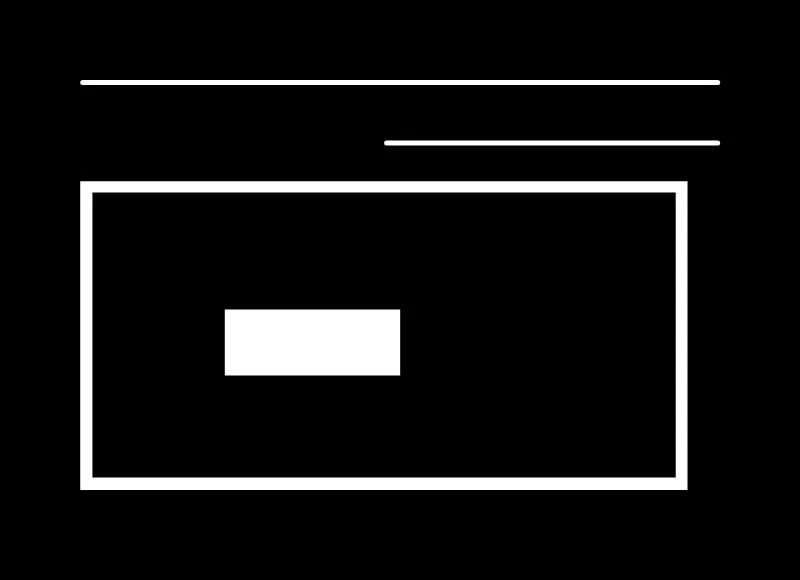

In [89]:
from google.colab import files

uploaded = files.upload()

nome_arquivo = next(iter(uploaded))

image2 = cv2.imread(nome_arquivo)

cv2_imshow(image2)

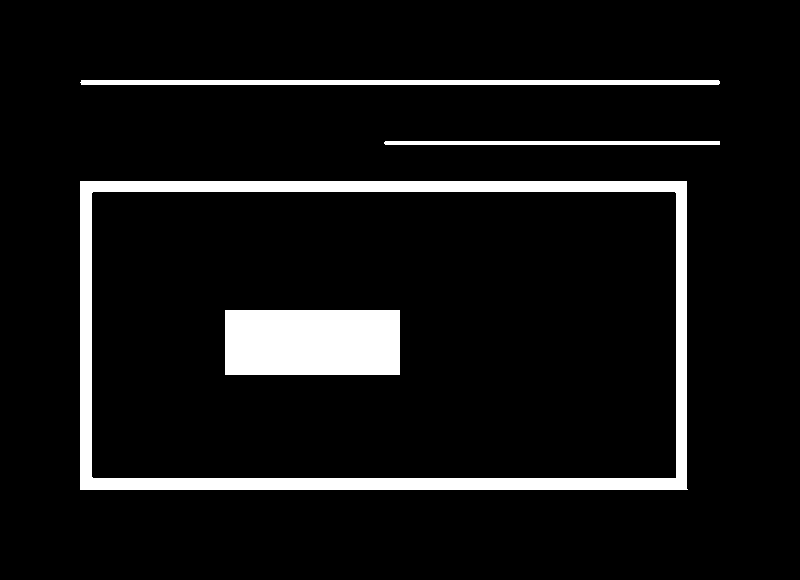

Hierarquia com RETR_TREE:
[[[ 3 -1  1 -1]
  [-1 -1  2  0]
  [-1 -1 -1  1]
  [ 4  0 -1 -1]
  [-1  3 -1 -1]]]


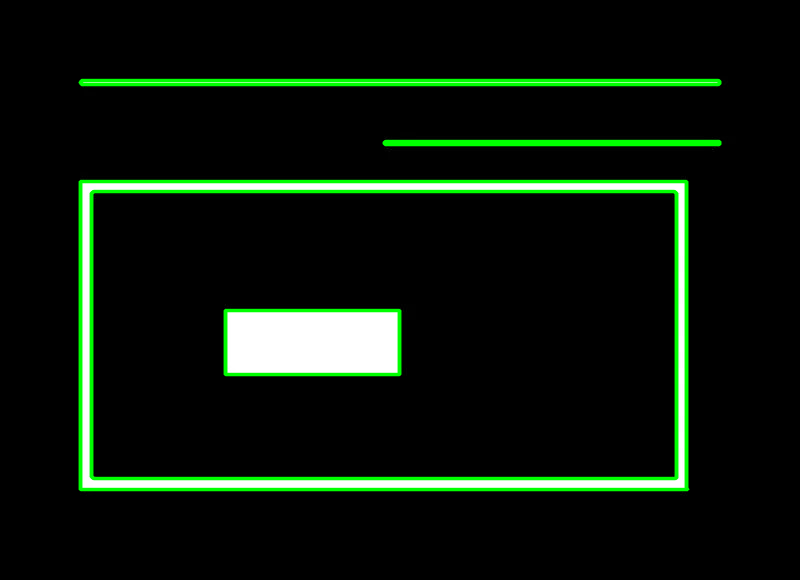

True

In [91]:
# Converte a imagem para escala de cinza
img_gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# Aplica a limiarização binária
ret, thresh2 = cv2.threshold(
    img_gray2,
    150,
    255,
    cv2.THRESH_BINARY
)

# Exibe a imagem binária
cv2_imshow(thresh2)
# Detecta os contornos e suas hierarquias
contours6, hierarchy6 = cv2.findContours(
    thresh2.copy(),
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_NONE
)

# Cria uma cópia da imagem original
image_copy7 = image2.copy()

# Desenha todos os contornos
cv2.drawContours(
    image_copy7,
    contours6,
    -1,
    (0, 255, 0),
    2,
    cv2.LINE_AA
)

# Exibe a hierarquia
print("Hierarquia com RETR_TREE:")
print(hierarchy6)

# Exibe a imagem com os contornos
cv2_imshow(image_copy7)

# Salva o resultado
cv2.imwrite(
    "contours_retr_tree.jpg",
    image_copy7
)